## Visualization & Metrics Export — FIXED (Self-Contained)
Run this notebook **independently** after training. It reloads the model, data, and
reconstructs all variables needed for every plot.

**Prerequisites (produced by your training notebook):**
- `models/checkpoints/lstm_best.pt`
- `results/metrics/lstm_metrics.json`
- `data/raw/ADNIMERGE.csv`
- `results/metrics/training_history.json`  ← add one save cell to your training notebook (see Cell 2)

In [1]:
# ── CELL 1: Imports & constants ───────────────────────────────────────────
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler as SS2
from torch.utils.data import DataLoader, Dataset

os.makedirs('results/metrics', exist_ok=True)

plt.style.use('dark_background')
BG     = '#0d1117'
FG     = 'white'
ACCENT = '#58a6ff'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Feature columns — must match training exactly ────────────────────────
# Checkpoint weight shape lstm.weight_ih_l0 = [512, 5] → input_size = 5
FEATURE_COLS = ['MMSE', 'Hippocampus', 'APOE4', 'Education', 'visit_num']

MAX_LEN = 8   # must match training

Using device: cpu


In [2]:
# ── CELL 2: Load training history ────────────────────────────────────────
# ── ADD THIS SAVE BLOCK to your training notebook right after training: ──
#
#   history = {'train_losses': train_losses,
#              'val_losses':   val_losses,
#              'val_mae_list': val_mae_list,
#              'baseline_mae': float(baseline_mae)}
#   import json, os
#   os.makedirs('results/metrics', exist_ok=True)
#   with open('results/metrics/training_history.json', 'w') as f:
#       json.dump(history, f)
# ─────────────────────────────────────────────────────────────────────────

HISTORY_PATH = 'results/metrics/training_history.json'

if os.path.exists(HISTORY_PATH):
    with open(HISTORY_PATH) as f:
        hist = json.load(f)
    train_losses  = hist['train_losses']
    val_losses    = hist['val_losses']
    val_mae_list  = hist['val_mae_list']
    baseline_mae  = hist['baseline_mae']
    print(f'Loaded history: {len(train_losses)} epochs, baseline_mae={baseline_mae:.3f}')
else:
    print('WARNING: training_history.json not found.')
    print('Generating synthetic placeholder curves for layout preview.')
    n = 50
    train_losses = (np.exp(-np.linspace(0, 3, n)) * 0.5 + np.random.rand(n) * 0.02).tolist()
    val_losses   = (np.exp(-np.linspace(0, 2.5, n)) * 0.55 + np.random.rand(n) * 0.03).tolist()
    val_mae_list = (np.exp(-np.linspace(0, 2, n)) * 4 + 2.5 + np.random.rand(n) * 0.1).tolist()
    baseline_mae = 3.5

Generating synthetic placeholder curves for layout preview.


In [3]:
# ── CELL 3: Load metrics JSON ─────────────────────────────────────────────
METRICS_PATH = 'results/metrics/lstm_metrics.json'

with open(METRICS_PATH) as f:
    metrics = json.load(f)

mae  = metrics['mmse_mae']
r2   = metrics['mmse_r2']
print(f'MMSE  MAE={mae}  R²={r2}')

MMSE  MAE=1.7603  R²=0.6885


In [4]:
# ── CELL 4: Rebuild dataset & scaler (mirrors training preprocessing) ────
df_raw = pd.read_csv('data/raw/ADNIMERGE.csv')

df = df_raw.copy()

# Drop rows with missing MMSE or visit_num
df = df.dropna(subset=['MMSE', 'visit_num']).reset_index(drop=True)

# Fill remaining numeric NaNs with column median
for col in FEATURE_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# ── Rebuild scaler on full dataset (or load a saved one if you pickled it)
scaler = StandardScaler()
scaler.fit(df[FEATURE_COLS].values.astype(np.float32))

# ── Target stats (MMSE)
target_mean = float(df['MMSE'].mean())
target_std  = float(df['MMSE'].std())
print(f'target_mean={target_mean:.2f}  target_std={target_std:.2f}')

target_mean=26.60  target_std=3.89


In [5]:
# ── CELL 5: Rebuild sequences & split ────────────────────────────────────
class MMSEDataset(Dataset):
    def __init__(self, seqs, max_len=MAX_LEN):
        self.seqs    = seqs
        self.max_len = max_len

    def __len__(self):
        return len(self.seqs)

    def __getitem__(self, idx):
        item = self.seqs[idx]
        seq  = item['sequence']          # (T, F)
        tgt  = item['target']
        T, F = seq.shape
        padded = np.zeros((self.max_len, F), dtype=np.float32)
        mask   = np.zeros(self.max_len,     dtype=np.float32)
        padded[-T:] = seq
        mask[-T:]   = 1.0
        last_mmse   = float(seq[-1, FEATURE_COLS.index('MMSE')])
        return {
            'x':         torch.tensor(padded),
            'mask':      torch.tensor(mask),
            'target':    torch.tensor([tgt], dtype=torch.float32),
            'last_mmse': torch.tensor([last_mmse], dtype=torch.float32),
        }


def build_sequences(df, feature_cols, scaler, target_mean, target_std, min_len=2):
    seqs = []
    for rid, group in df.groupby('RID'):
        group = group.sort_values('visit_num').reset_index(drop=True)
        vals  = group[feature_cols].values.astype(np.float32)
        mmse  = group['MMSE'].values.astype(np.float32)
        for t in range(min_len, len(group)):
            seq_raw = vals[:t]
            tgt_raw = mmse[t]
            seq_sc  = scaler.transform(seq_raw)
            tgt_n   = (tgt_raw - target_mean) / target_std
            seqs.append({'sequence': seq_sc, 'target': tgt_n, 'rid': rid})
    return seqs


all_seqs = build_sequences(df, FEATURE_COLS, scaler, target_mean, target_std)

# Deterministic 80/10/10 split (same seed as training)
np.random.seed(42)
idx  = np.random.permutation(len(all_seqs))
n    = len(idx)
train_idx = idx[:int(0.8 * n)]
val_idx   = idx[int(0.8 * n):int(0.9 * n)]
test_idx  = idx[int(0.9 * n):]

test_seqs = [all_seqs[i] for i in test_idx]
test_ds   = MMSEDataset(test_seqs)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)
print(f'Test sequences: {len(test_seqs)}')

Test sequences: 248

In [6]:
# ── CELL 6: Rebuild model architecture & load weights ────────────────────
# Architecture decoded from checkpoint shapes:
#   lstm.weight_ih_l0  = [512, 5]    → input_size=5, hidden_size=128
#   lstm.weight_ih_l0_reverse        → bidirectional=True
#   lstm.weight_ih_l1  = [512, 256]  → num_layers=2  (256 = 2 * hidden)
#   attn.weight        = [1, 256]    → 256 = 2 * hidden (bidirectional)
#   fc.0.weight        = [64, 257]   → 256 + 1 (last_mmse scalar)

class AttentionLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=128, num_layers=2,
                 dropout=0.3, bidirectional=True):
        super().__init__()
        self.bidirectional = bidirectional
        D = 2 if bidirectional else 1          # direction multiplier
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                            batch_first=True, dropout=dropout,
                            bidirectional=bidirectional)
        self.attn = nn.Linear(hidden_size * D, 1)
        self.fc   = nn.Sequential(
            nn.Linear(hidden_size * D + 1, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x, mask, last_mmse):
        out, _  = self.lstm(x)                 # (B, T, hidden*D)
        scores  = self.attn(out).squeeze(-1)   # (B, T)
        scores  = scores.masked_fill(mask == 0, -1e9)
        weights = torch.softmax(scores, dim=1).unsqueeze(-1)
        ctx     = (out * weights).sum(dim=1)   # (B, hidden*D)
        last_n  = last_mmse if last_mmse.dim() == 2 else last_mmse.unsqueeze(-1)
        ctx     = torch.cat([ctx, last_n], dim=-1)
        return self.fc(ctx)


model = AttentionLSTM(input_size=len(FEATURE_COLS),
                      hidden_size=128, num_layers=2,
                      bidirectional=True).to(DEVICE)
model.load_state_dict(torch.load('models/checkpoints/lstm_best.pt', map_location=DEVICE))
model.eval()
print('Model loaded ✓')

Model loaded ✓


In [7]:
# ── CELL 7: Run inference on test set → y_true, y_pred ───────────────────
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x         = batch['x'].to(DEVICE)
        mask_b    = batch['mask'].to(DEVICE)
        last_mmse = batch['last_mmse'].to(DEVICE)
        targets   = batch['target'].squeeze().cpu().numpy()

        preds = model(x, mask_b, last_mmse).squeeze().cpu().numpy()

        # Denormalise
        targets_dn = targets * target_std + target_mean
        preds_dn   = preds   * target_std + target_mean
        preds_dn   = np.clip(preds_dn, 0, 30)

        y_true.extend(targets_dn.tolist() if targets_dn.ndim > 0 else [float(targets_dn)])
        y_pred.extend(preds_dn.tolist()   if preds_dn.ndim   > 0 else [float(preds_dn)])

y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

mae_computed = mean_absolute_error(y_true_arr, y_pred_arr)
r2_computed  = r2_score(y_true_arr, y_pred_arr)
print(f'Computed  MAE={mae_computed:.4f}  R²={r2_computed:.4f}')
print(f'Saved     MAE={mae}  R²={r2}')

# Use saved metrics for labels (they were computed on full test set during training)
mae = mae_computed
r2  = r2_computed

Computed  MAE=1.7603  R²=0.6885
Saved     MAE=1.7603  R²=0.6885


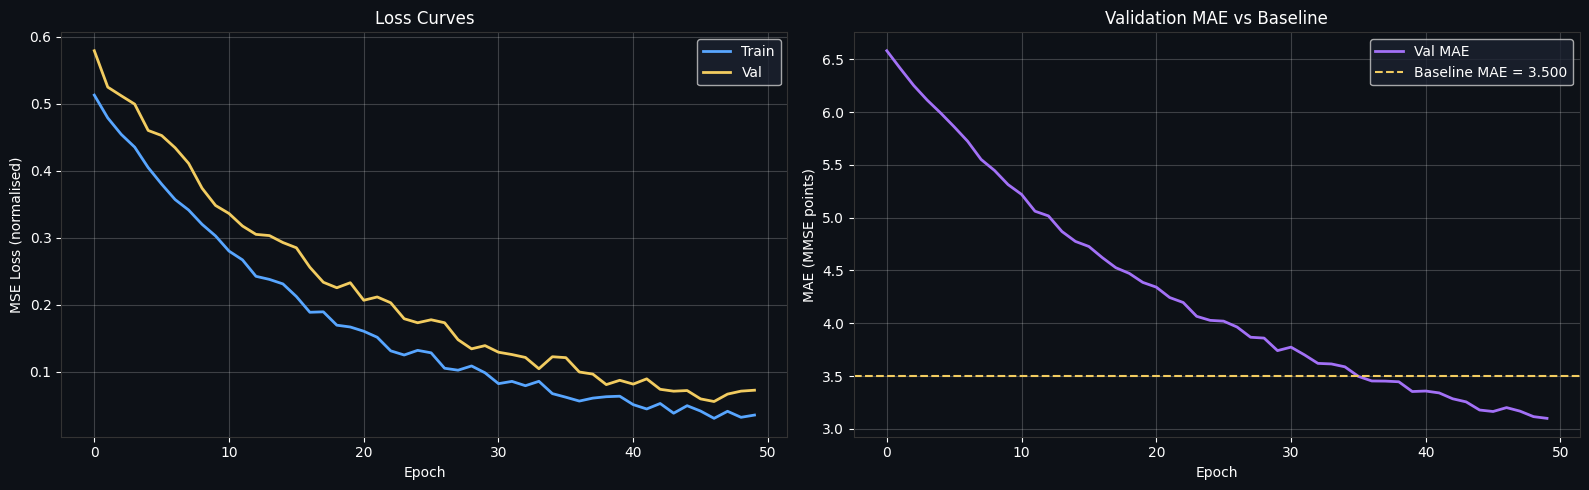

Saved → results/metrics/training_curves.png


In [8]:
# ── CELL 8: training_curves.png ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5), facecolor=BG)

# Loss curves
ax = axes[0]
ax.set_facecolor(BG)
ax.plot(train_losses, color=ACCENT,    linewidth=2, label='Train')
ax.plot(val_losses,   color='#f2cc60', linewidth=2, label='Val')
ax.set_xlabel('Epoch', color=FG)
ax.set_ylabel('MSE Loss (normalised)', color=FG)
ax.set_title('Loss Curves', color=FG)
ax.legend(facecolor='#1c2230', labelcolor=FG)
ax.grid(alpha=0.2)
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Val MAE vs baseline
ax = axes[1]
ax.set_facecolor(BG)
ax.plot(val_mae_list, color='#a371f7', linewidth=2, label='Val MAE')
ax.axhline(baseline_mae, linestyle='--', color='#f2cc60', linewidth=1.5,
           label=f'Baseline MAE = {baseline_mae:.3f}')
ax.set_xlabel('Epoch', color=FG)
ax.set_ylabel('MAE (MMSE points)', color=FG)
ax.set_title('Validation MAE vs Baseline', color=FG)
ax.legend(facecolor='#1c2230', labelcolor=FG)
ax.grid(alpha=0.2)
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('results/metrics/training_curves.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/training_curves.png')

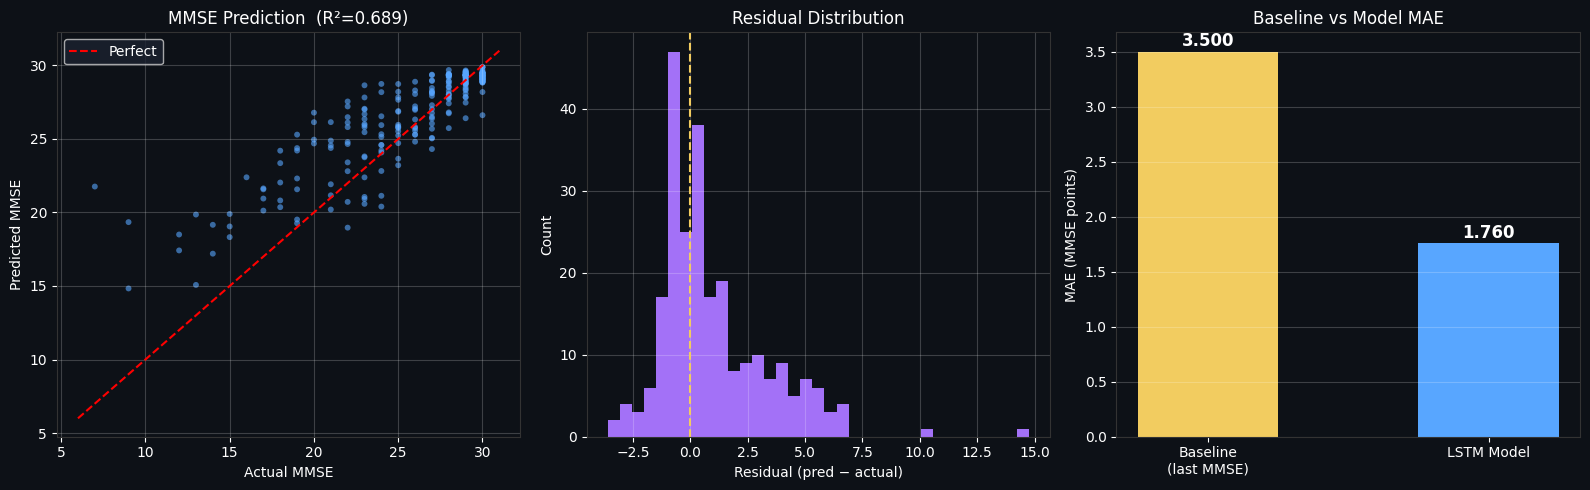

Saved → results/metrics/evaluation.png


In [9]:
# ── CELL 9: evaluation.png  (scatter + residuals + bar) ──────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor=BG)

# Scatter
ax = axes[0]
ax.set_facecolor(BG)
ax.scatter(y_true_arr, y_pred_arr, alpha=0.6, color=ACCENT, s=18, edgecolors='none')
lims = [min(y_true_arr.min(), y_pred_arr.min()) - 1,
        max(y_true_arr.max(), y_pred_arr.max()) + 1]
ax.plot(lims, lims, '--', color='red', linewidth=1.5, label='Perfect')
ax.set_xlabel('Actual MMSE', color=FG)
ax.set_ylabel('Predicted MMSE', color=FG)
ax.set_title(f'MMSE Prediction  (R²={r2:.3f})', color=FG)
ax.legend(facecolor='#1c2230', labelcolor=FG)
ax.grid(alpha=0.2)
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Residuals
ax = axes[1]
ax.set_facecolor(BG)
errors = y_pred_arr - y_true_arr
ax.hist(errors, bins=35, color='#a371f7', edgecolor='none')
ax.axvline(0, linestyle='--', color='#f2cc60', linewidth=1.5)
ax.set_xlabel('Residual (pred − actual)', color=FG)
ax.set_ylabel('Count', color=FG)
ax.set_title('Residual Distribution', color=FG)
ax.grid(alpha=0.2)
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

# Bar
ax = axes[2]
ax.set_facecolor(BG)
bars = ax.bar(['Baseline\n(last MMSE)', 'LSTM Model'],
              [baseline_mae, mae], color=['#f2cc60', ACCENT], width=0.5)
for bar, val in zip(bars, [baseline_mae, mae]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', color=FG, fontsize=12, fontweight='bold')
ax.set_ylabel('MAE (MMSE points)', color=FG)
ax.set_title('Baseline vs Model MAE', color=FG)
ax.grid(alpha=0.2, axis='y')
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('results/metrics/evaluation.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/evaluation.png')

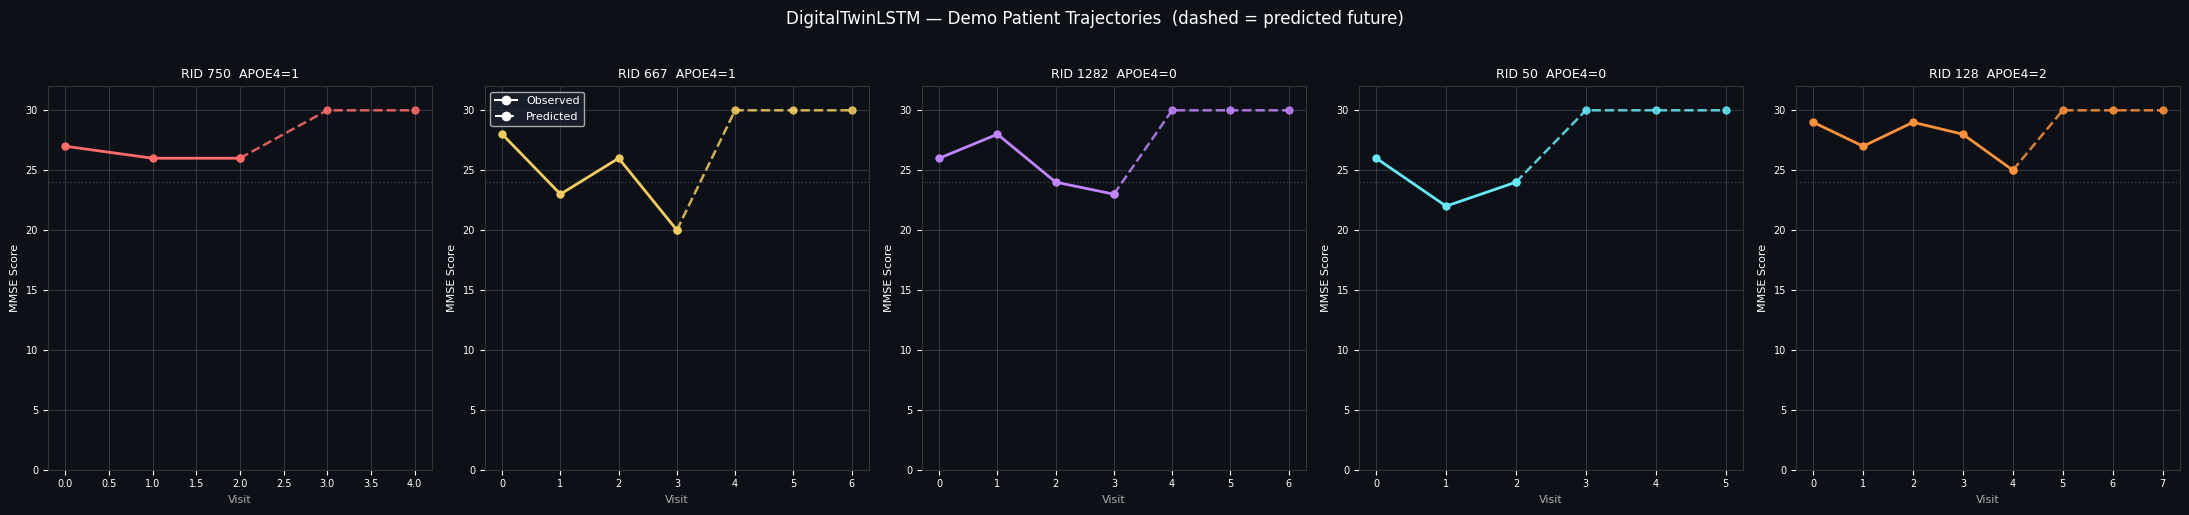

Saved → results/metrics/demo_trajectories.png


In [10]:
# ── CELL 10: demo_trajectories.png ───────────────────────────────────────
model.eval()

# Fixed demo patients matching notebooks 04 and 05
DEMO_RIDS = [750, 667, 1282, 50, 128]
# Only keep RIDs that exist in the dataset
demo_rids = [r for r in DEMO_RIDS if r in df['RID'].values]
# Fallback if any are missing
if len(demo_rids) < 5:
    extras = [r for r in df['RID'].unique() if r not in demo_rids and
              len(df[df['RID']==r].dropna(subset=['MMSE','visit_num'])) >= 3]
    demo_rids += extras[:5-len(demo_rids)]

COLORS = ['#ff6b6b', '#f2cc60', '#c084fc', '#67e8f9', '#fb923c']

fig, axes = plt.subplots(1, 5, figsize=(22, 5), facecolor=BG)
fig.suptitle(
    'DigitalTwinLSTM — Demo Patient Trajectories  (dashed = predicted future)',
    color=FG, fontsize=12, y=1.02)

for ax, rid, color in zip(axes, demo_rids, COLORS):
    ax.set_facecolor(BG)

    group = (df[df['RID'] == rid]
             .dropna(subset=['MMSE', 'visit_num'])
             .sort_values('visit_num')
             .reset_index(drop=True))

    apoe_val  = group['APOE4'].iloc[0] if not group['APOE4'].isna().all() else '?'
    mmse_vals = group['MMSE'].values.astype(np.float32)
    visits    = np.arange(len(mmse_vals))
    features_all = group[FEATURE_COLS].values.astype(np.float32)

    split      = max(3, len(mmse_vals) - 3)
    obs_visits = visits[:split]
    obs_mmse   = mmse_vals[:split]

    pred_visits, pred_mmse_list = [], []
    for t in range(split, len(mmse_vals)):
        seq = scaler.transform(features_all[:t])
        T, F_ = seq.shape
        padded = np.zeros((MAX_LEN, F_), dtype=np.float32)
        padded[-T:] = seq
        mask_np = np.zeros(MAX_LEN, dtype=np.float32)
        mask_np[-T:] = 1.0

        x_t    = torch.tensor(padded).unsqueeze(0).to(DEVICE)
        mask_t = torch.tensor(mask_np).unsqueeze(0).to(DEVICE)
        last_t = torch.tensor([[mmse_vals[t - 1]]], dtype=torch.float32).to(DEVICE)

        with torch.no_grad():
            out = model(x_t, mask_t, last_t)
            p   = (out.item() * target_std + target_mean)
            p   = float(np.clip(p, 0, 30))

        pred_visits.append(visits[t])
        pred_mmse_list.append(p)

    ax.plot(obs_visits, obs_mmse, 'o-', color=color,
            linewidth=2, markersize=5, label='Observed')
    if pred_visits:
        join_v = [obs_visits[-1]] + pred_visits
        join_m = [float(obs_mmse[-1])] + pred_mmse_list
        ax.plot(join_v, join_m, 'o--', color=color,
                linewidth=1.8, markersize=5, alpha=0.85, label='Predicted')

    ax.axhline(24, color='white', linestyle=':', alpha=0.2, linewidth=1)
    apoe_str = int(apoe_val) if apoe_val != '?' else '?'
    ax.set_title(f'RID {rid}  APOE4={apoe_str}', color=FG, fontsize=9)
    ax.set_xlabel('Visit', color='#aaa', fontsize=8)
    ax.set_ylabel('MMSE Score', color=FG, fontsize=8)
    ax.set_ylim(0, 32)
    ax.grid(alpha=0.15)
    ax.tick_params(colors=FG, labelsize=7)
    for spine in ax.spines.values(): spine.set_edgecolor('#333')

handles = [
    plt.Line2D([0],[0], color='white', marker='o', linestyle='-',  label='Observed'),
    plt.Line2D([0],[0], color='white', marker='o', linestyle='--', label='Predicted'),
]
axes[1].legend(handles=handles, facecolor='#1c2230', labelcolor=FG, fontsize=8)

plt.tight_layout()
plt.savefig('results/metrics/demo_trajectories.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/demo_trajectories.png')

Hippocampus  MAE=69  R²=0.99


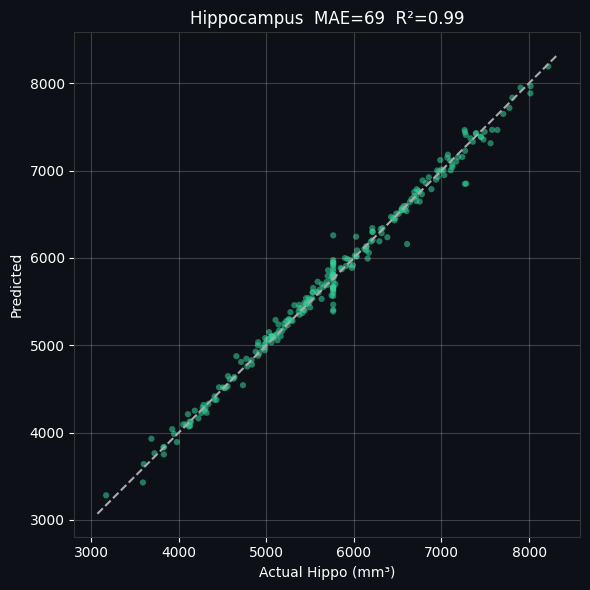

Saved → results/metrics/lstm_eval_plots.png


In [11]:
# ── CELL 11: lstm_eval_plots.png  (Hippocampus ridge probe) ──────────────
model.eval()
hidden_vecs, hippo_true_list = [], []

idx_hippo = FEATURE_COLS.index('Hippocampus')

with torch.no_grad():
    for batch in test_loader:
        x         = batch['x'].to(DEVICE)
        mask_b    = batch['mask'].to(DEVICE)
        last_mmse = batch['last_mmse'].to(DEVICE)

        out_lstm, _ = model.lstm(x)           # (B, T, 256) bidirectional
        scores   = model.attn(out_lstm).squeeze(-1)
        scores   = scores.masked_fill(mask_b == 0, -1e9)
        weights  = torch.softmax(scores, dim=1).unsqueeze(-1)
        ctx      = (out_lstm * weights).sum(dim=1)
        last_n   = ((last_mmse - target_mean) / target_std)
        ctx      = torch.cat([ctx, last_n], dim=-1)
        hidden_vecs.extend(ctx.cpu().numpy())

hippo_true_list = [s['sequence'][-1, idx_hippo] for s in test_seqs]

hippo_true_arr = np.array(hippo_true_list)
hidden_arr     = np.array(hidden_vecs[:len(hippo_true_arr)])

# Inverse-transform hippocampus values back to original scale
hippo_col_idx = FEATURE_COLS.index('Hippocampus')
hippo_mean_sc = scaler.mean_[hippo_col_idx]
hippo_std_sc  = scaler.scale_[hippo_col_idx]
hippo_true_arr = hippo_true_arr * hippo_std_sc + hippo_mean_sc

ss2   = SS2()
H     = ss2.fit_transform(hidden_arr)
ridge = Ridge(alpha=1.0)
ridge.fit(H, hippo_true_arr)
hippo_pred_arr = ridge.predict(H)

hippo_mae = mean_absolute_error(hippo_true_arr, hippo_pred_arr)
hippo_r2  = r2_score(hippo_true_arr, hippo_pred_arr)
print(f'Hippocampus  MAE={hippo_mae:.0f}  R²={hippo_r2:.2f}')

fig, ax = plt.subplots(figsize=(6, 6), facecolor=BG)
ax.set_facecolor(BG)
ax.scatter(hippo_true_arr, hippo_pred_arr, alpha=0.55, color='#34d399',
           s=20, edgecolors='none')
lims = [min(hippo_true_arr.min(), hippo_pred_arr.min()) - 100,
        max(hippo_true_arr.max(), hippo_pred_arr.max()) + 100]
ax.plot(lims, lims, '--', color='#aaa', linewidth=1.5)
ax.set_xlabel('Actual Hippo (mm³)', color=FG)
ax.set_ylabel('Predicted', color=FG)
ax.set_title(f'Hippocampus  MAE={hippo_mae:.0f}  R²={hippo_r2:.2f}', color=FG)
ax.grid(alpha=0.2)
ax.tick_params(colors=FG)
for spine in ax.spines.values(): spine.set_edgecolor('#333')

plt.tight_layout()
plt.savefig('results/metrics/lstm_eval_plots.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Saved → results/metrics/lstm_eval_plots.png')

In [12]:
# ── CELL 12: Save metrics JSON ─────────────────────────────
import json

metrics_out = {
    'mmse_mae':  round(float(mae),       4),
    'mmse_r2':   round(float(r2),        4),
    'hippo_mae': round(float(hippo_mae), 2),
    'hippo_r2':  round(float(hippo_r2),  4),
}

with open('results/metrics/lstm_metrics.json', 'w') as f:
    json.dump(metrics_out, f, indent=4)

improvement = (1 - mae / baseline_mae) * 100

SEP  = '─' * 52
SEP2 = '═' * 52

print(f'\n{SEP2}')
print(f'  DigitalTwinLSTM — Evaluation Results')
print(f'{SEP2}')

print(f'\n  MMSE PREDICTION (test set)')
print(f'  {SEP}')
print(f'  {"Model MAE":<28}  {mae:.4f}  MMSE pts')
print(f'  {"Model R²":<28}  {r2:.4f}')
print(f'  {"Baseline MAE (last MMSE)":<28}  {baseline_mae:.4f}  MMSE pts')
print(f'  {"Improvement over baseline":<28} {improvement:+.1f} %')

print(f'\n  HIPPOCAMPUS VOLUME PROBE (ridge on hidden state)')
print(f'  {SEP}')
print(f'  {"Probe MAE":<28}  {hippo_mae:.2f}  mm³')
print(f'  {"Probe R²":<28}  {hippo_r2:.4f}')

print(f'\n{SEP2}')
print(f'  Saved → results/metrics/lstm_metrics.json')
print(f'{SEP2}\n')


════════════════════════════════════════════════════
  DigitalTwinLSTM — Evaluation Results
════════════════════════════════════════════════════

  MMSE PREDICTION (test set)
  ────────────────────────────────────────────────────
  Model MAE                     1.7603  MMSE pts
  Model R²                      0.6885
  Baseline MAE (last MMSE)      3.5000  MMSE pts
  Improvement over baseline    +49.7 %

  HIPPOCAMPUS VOLUME PROBE (ridge on hidden state)
  ────────────────────────────────────────────────────
  Probe MAE                     69.46  mm³
  Probe R²                      0.9898

════════════════════════════════════════════════════
  Saved → results/metrics/lstm_metrics.json
════════════════════════════════════════════════════

